In [53]:
"""
ACDC Dataset Loader for Cardiac MRI
"""

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import nibabel as nib
from pathlib import Path
from typing import Tuple, Dict, List
import cv2
import random


class ACDCDataset(Dataset):
    """
    ACDC Challenge Dataset Loader
    Loads cardiac MRI sequences from NIfTI files
    """
    
    def __init__(
        self,
        data_root: str,
        split: str = "train",
        temporal_frames: int = 20,
        image_size: Tuple[int, int] = (128, 128),
        augment: bool = False,
        slice_selection: str = "mid"
    ):
        self.data_root = Path(data_root)
        self.split = split
        self.temporal_frames = temporal_frames
        self.image_size = image_size
        self.augment = augment
        self.slice_selection = slice_selection
        
        self.samples = self._load_samples()
        print(f"Loaded {len(self.samples)} samples for {self.split} split")
    
    def _load_samples(self) -> List[Dict]:
        """Load all patient samples"""
        samples = []
        
        if self.split in ["train", "val"]:
            # Try different possible directory structures
            training_dir = self.data_root / "training_ACDC"
            if not training_dir.exists():
                training_dir = self.data_root / "training"
            if not training_dir.exists():
                training_dir = self.data_root / "database" / "training"
            
            patient_dirs = sorted(training_dir.glob("patient*"))
            
            # Split into train/val (80/20)
            n_train = int(len(patient_dirs) * 0.8)
            if self.split == "train":
                patient_dirs = patient_dirs[:n_train]
            else:
                patient_dirs = patient_dirs[n_train:]
        else:
            # Try different possible directory structures
            testing_dir = self.data_root / "testing_ACDC"
            if not testing_dir.exists():
                testing_dir = self.data_root / "testing"
            if not testing_dir.exists():
                testing_dir = self.data_root / "database" / "testing"
            patient_dirs = sorted(testing_dir.glob("patient*"))
        
        for patient_dir in patient_dirs:
            ed_frame = None
            es_frame = None
            
            info_file = patient_dir / "Info.cfg"
            if info_file.exists():
                with open(info_file, 'r') as f:
                    for line in f:
                        if 'ED:' in line:
                            ed_frame = int(line.split(':')[1].strip())
                        if 'ES:' in line:
                            es_frame = int(line.split(':')[1].strip())
            
            frame_files = sorted(patient_dir.glob("*_frame*.nii.gz"))
            frame_files = [f for f in frame_files if '_gt' not in f.name]
            
            for frame_file in frame_files:
                frame_num = frame_file.stem.split('_frame')[1].split('.')[0]
                gt_file = patient_dir / f"{patient_dir.name}_frame{frame_num}_gt.nii.gz"
                
                if gt_file.exists():
                    samples.append({
                        'image_path': frame_file,
                        'label_path': gt_file,
                        'patient_id': patient_dir.name,
                        'frame_num': frame_num,
                        'is_ed': (ed_frame and int(frame_num) == ed_frame),
                        'is_es': (es_frame and int(frame_num) == es_frame)
                    })
        
        return samples
    
    def __len__(self) -> int:
        return len(self.samples)
    
    def _load_nifti(self, path: Path) -> np.ndarray:
        """Load NIfTI file"""
        nii = nib.load(str(path))
        data = nii.get_fdata()
        return data
    
    def _select_slice(self, volume: np.ndarray) -> np.ndarray:
        """Select slice from 3D volume"""
        if self.slice_selection == "mid":
            mid_slice = volume.shape[2] // 2
            return volume[:, :, mid_slice]
        elif isinstance(self.slice_selection, int):
            return volume[:, :, self.slice_selection]
        else:
            mid_slice = volume.shape[2] // 2
            return volume[:, :, mid_slice]
    
    def _normalize(self, image: np.ndarray) -> np.ndarray:
        """Normalize image to [0, 1]"""
        image = image.astype(np.float32)
        nonzero = image[image > 0]
        if len(nonzero) > 0:
            pmin, pmax = np.percentile(nonzero, [1, 99])
            image = np.clip(image, pmin, pmax)
            if pmax > pmin:
                image = (image - pmin) / (pmax - pmin)
        return image
    
    def _resize(self, image: np.ndarray, is_label: bool = False) -> np.ndarray:
        """Resize image to target size"""
        if image.shape[:2] == self.image_size:
            return image
        
        interp = cv2.INTER_NEAREST if is_label else cv2.INTER_LINEAR
        resized = cv2.resize(image, self.image_size, interpolation=interp)
        return resized
    
    def _augment_frame(self, image: np.ndarray, label: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Apply data augmentation"""
        if not self.augment:
            return image, label
        
        # Random rotation
        if random.random() > 0.5:
            angle = random.uniform(-15, 15)
            h, w = image.shape
            center = (w / 2, h / 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR)
            label = cv2.warpAffine(label, M, (w, h), flags=cv2.INTER_NEAREST)
        
        # Random scaling
        if random.random() > 0.5:
            scale = random.uniform(0.9, 1.1)
            h, w = image.shape
            new_h, new_w = int(h * scale), int(w * scale)
            image_scaled = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
            label_scaled = cv2.resize(label, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
            
            if scale > 1:
                start_h = (new_h - h) // 2
                start_w = (new_w - w) // 2
                image = image_scaled[start_h:start_h+h, start_w:start_w+w]
                label = label_scaled[start_h:start_h+h, start_w:start_w+w]
            else:
                pad_h = (h - new_h) // 2
                pad_w = (w - new_w) // 2
                image = np.pad(image_scaled, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w)), mode='constant')
                label = np.pad(label_scaled, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w)), mode='constant')
        
        # Random intensity shift
        if random.random() > 0.5:
            shift = random.uniform(-0.1, 0.1)
            image = np.clip(image + shift, 0, 1)
        
        # Random horizontal flip
        if random.random() > 0.5:
            image = np.fliplr(image).copy()
            label = np.fliplr(label).copy()
        
        return image, label
    
    def _create_temporal_sequence(
        self, 
        frame: np.ndarray, 
        label: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Create temporal sequence by simulating cardiac motion"""
        sequence_images = []
        sequence_labels = []
        
        for t in range(self.temporal_frames):
            phase = 2 * np.pi * t / self.temporal_frames
            scale = 1.0 + 0.05 * np.sin(phase)
            
            h, w = frame.shape
            center = (w / 2, h / 2)
            M = cv2.getRotationMatrix2D(center, 0, scale)
            
            frame_t = cv2.warpAffine(frame, M, (w, h), flags=cv2.INTER_LINEAR)
            label_t = cv2.warpAffine(label, M, (w, h), flags=cv2.INTER_NEAREST)
            
            if self.augment and t > 0:
                noise = np.random.normal(0, 0.02, frame_t.shape).astype(np.float32)
                frame_t = np.clip(frame_t + noise, 0, 1)
            
            sequence_images.append(frame_t)
            sequence_labels.append(label_t)
        
        return np.array(sequence_images), np.array(sequence_labels)
    
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        sample = self.samples[idx]
        
        image_vol = self._load_nifti(sample['image_path'])
        label_vol = self._load_nifti(sample['label_path'])
        
        image_slice = self._select_slice(image_vol)
        label_slice = self._select_slice(label_vol)
        
        image_slice = self._normalize(image_slice)
        
        image_slice = self._resize(image_slice, is_label=False)
        label_slice = self._resize(label_slice, is_label=True)
        
        image_slice, label_slice = self._augment_frame(image_slice, label_slice)
        
        image_sequence, label_sequence = self._create_temporal_sequence(
            image_slice, label_slice
        )
        
        image_tensor = torch.from_numpy(image_sequence).float()
        label_tensor = torch.from_numpy(label_sequence).long()
        
        return {
            'image': image_tensor,
            'label': label_tensor,
            'patient_id': sample['patient_id'],
            'frame_num': sample['frame_num'],
            'idx': idx
        }


def get_acdc_dataloaders(
    data_root: str,
    batch_size: int = 4,
    num_workers: int = 0,
    temporal_frames: int = 20,
    image_size: Tuple[int, int] = (128, 128)
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Create ACDC dataloaders"""
    
    print(f"Loading ACDC dataset from: {data_root}")
    
    train_dataset = ACDCDataset(
        data_root=data_root,
        split="train",
        temporal_frames=temporal_frames,
        image_size=image_size,
        augment=True
    )
    
    val_dataset = ACDCDataset(
        data_root=data_root,
        split="val",
        temporal_frames=temporal_frames,
        image_size=image_size,
        augment=False
    )
    
    test_dataset = ACDCDataset(
        data_root=data_root,
        split="test",
        temporal_frames=temporal_frames,
        image_size=image_size,
        augment=False
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader, test_loader

In [54]:
from __future__ import annotations  # Enable postponed evaluation of annotations
class Config:
    # Project paths
    PROJECT_NAME = "cardiac_motion_foundation_model"
    DATA_DIR = "./data"
    OUTPUT_DIR = "./outputs"
    CHECKPOINT_DIR = "./checkpoints"
    
    # ============ ADD THESE TWO LINES ============
    USE_ACDC = True  # Set to True to use ACDC dataset
    ACDC_DATA_ROOT = "."  # Points to workspace root where training_ACDC and testing_ACDC are located
    # =============================================
    
    # Data parameters
    IMAGE_SIZE = (128, 128)
    TEMPORAL_FRAMES = 20
    NUM_SLICES = 10  # Number of slices per volume
    
    # Model architecture
    ENCODER_NAME = "resnet18"  # Options: resnet18, resnet34, efficientnet
    HIDDEN_DIM = 256
    LATENT_DIM = 128
    TEMPORAL_ENCODER_TYPE = "lstm"  # Options: lstm, transformer, conv3d
    
    # Self-supervised pretraining parameters
    PRETRAIN_EPOCHS = 50
    PRETRAIN_BATCH_SIZE = 8
    PRETRAIN_LR = 1e-4
    PRETRAIN_WEIGHT_DECAY = 1e-5
    
    # SSL objectives
    USE_CONTRASTIVE = True
    USE_RECONSTRUCTION = True
    USE_TEMPORAL_PREDICTION = True
    USE_MOTION_CONSISTENCY = True
    
    # Contrastive learning
    TEMPERATURE = 0.07
    CONTRASTIVE_WEIGHT = 1.0
    
    # Reconstruction
    RECONSTRUCTION_WEIGHT = 1.0
    
    # Temporal prediction
    TEMPORAL_PREDICTION_WEIGHT = 0.5
    PREDICTION_HORIZON = 3  # Predict next N frames
    
    # Motion consistency
    MOTION_CONSISTENCY_WEIGHT = 0.3
    OPTICAL_FLOW_WEIGHT = 0.2
    
    # Fine-tuning parameters
    FINETUNE_EPOCHS = 30
    FINETUNE_BATCH_SIZE = 4
    FINETUNE_LR = 5e-5
    FINETUNE_WEIGHT_DECAY = 1e-5
    
    # Segmentation parameters
    NUM_CLASSES = 4  # Background, LV, RV, Myocardium
    SEGMENTATION_LOSS = "dice_ce"  # dice, ce, dice_ce, focal
    
    # Few-shot learning
    FEW_SHOT_K = [1, 5, 10, 20]  # Number of labeled samples
    
    # Data augmentation
    USE_AUGMENTATION = True
    ROTATION_RANGE = 15
    SCALE_RANGE = (0.9, 1.1)
    INTENSITY_SHIFT = 0.1
    ELASTIC_DEFORM = True
    
    # Training parameters
    OPTIMIZER = "adamw"
    SCHEDULER = "cosine"
    WARMUP_EPOCHS = 5
    GRADIENT_CLIP = 1.0
    MIXED_PRECISION = True
    
    # Evaluation
    EVAL_EVERY_N_EPOCHS = 5
    SAVE_BEST_ONLY = True
    METRICS = ["dice", "hausdorff", "ejection_fraction", "temporal_consistency"]
    
    # Hardware
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS = 0
    PIN_MEMORY = True
    
    # Reproducibility
    RANDOM_SEED = 42
    DETERMINISTIC = True
    
    # Logging
    USE_TENSORBOARD = True
    USE_WANDB = False
    LOG_INTERVAL = 10
    SAVE_VISUALIZATIONS = True
    
    @classmethod
    def update(cls, **kwargs):
        """Update configuration with custom parameters"""
        for key, value in kwargs.items():
            if hasattr(cls, key):
                setattr(cls, key, value)
            else:
                print(f"Warning: {key} is not a valid config parameter")
    
    @classmethod
    def display(cls):
        """Display current configuration"""
        print("=" * 50)
        print("Configuration:")
        print("=" * 50)
        for key, value in cls.__dict__.items():
            if not key.startswith('_') and not callable(value):
                print(f"{key}: {value}")
        print("=" * 50)

In [55]:
"""
Motion-Aware Foundation Model Architecture
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Optional, List
import torchvision.models as models


class SpatialEncoder(nn.Module):
    """Spatial encoder for individual frames using ResNet"""
    
    def __init__(self, backbone: str = "resnet18", pretrained: bool = True, output_dim: int = 256):
        super().__init__()
        
        # Load backbone
        if backbone == "resnet18":
            resnet = models.resnet18(pretrained=pretrained)
            feature_dim = 512
        elif backbone == "resnet34":
            resnet = models.resnet34(pretrained=pretrained)
            feature_dim = 512
        elif backbone == "resnet50":
            resnet = models.resnet50(pretrained=pretrained)
            feature_dim = 2048
        else:
            raise ValueError(f"Unsupported backbone: {backbone}")
        
        # Modify first conv for single channel input
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            self.conv1.weight.data = resnet.conv1.weight.data.mean(dim=1, keepdim=True)
        
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.projection = nn.Sequential(
            nn.Linear(feature_dim, output_dim),
            nn.ReLU(),
            nn.Linear(output_dim, output_dim)
        )
        
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x: (B, 1, H, W)
        Returns:
            features: (B, 512, H/32, W/32)
            embedding: (B, output_dim)
        """
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        features = self.layer4(x)
        
        pooled = self.avgpool(features)
        pooled = torch.flatten(pooled, 1)
        embedding = self.projection(pooled)
        
        return features, embedding


class MotionEncoder(nn.Module):
    """Encode optical flow and motion patterns"""
    
    def __init__(self, input_channels: int = 2, output_dim: int = 128):
        super().__init__()
        
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.projection = nn.Sequential(
            nn.Linear(128, output_dim),
            nn.ReLU(),
            nn.Linear(output_dim, output_dim)
        )
    
    def forward(self, flow: torch.Tensor) -> torch.Tensor:
        """
        Args:
            flow: (B, 2, H, W)
        Returns:
            motion_embedding: (B, output_dim)
        """
        features = self.conv_blocks(flow)
        features = features.view(features.size(0), -1)
        embedding = self.projection(features)
        return embedding


class TemporalEncoder(nn.Module):
    """Encode temporal sequences using LSTM"""
    
    def __init__(self, input_dim: int = 256, hidden_dim: int = 256, num_layers: int = 2):
        super().__init__()
        
        self.temporal_encoder = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.output_dim = hidden_dim * 2
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, T, D)
        Returns:
            encoded: (B, T, output_dim)
        """
        encoded, _ = self.temporal_encoder(x)
        return encoded


class MotionAwareFoundationModel(nn.Module):
    """Complete motion-aware foundation model"""
    
    def __init__(
        self,
        spatial_backbone: str = "resnet18",
        hidden_dim: int = 256,
        latent_dim: int = 128,
        temporal_encoder_type: str = "lstm",
        num_temporal_layers: int = 2
    ):
        super().__init__()
        
        self.spatial_encoder = SpatialEncoder(
            backbone=spatial_backbone,
            pretrained=True,
            output_dim=hidden_dim
        )
        
        self.motion_encoder = MotionEncoder(
            input_channels=2,
            output_dim=latent_dim
        )
        
        self.temporal_encoder = TemporalEncoder(
            input_dim=hidden_dim + latent_dim,
            hidden_dim=hidden_dim,
            num_layers=num_temporal_layers
        )
        
        self.projection_head = nn.Sequential(
            nn.Linear(self.temporal_encoder.output_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        self.prediction_head = nn.Sequential(
            nn.Linear(self.temporal_encoder.output_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
    
    def compute_optical_flow(self, frames: torch.Tensor) -> torch.Tensor:
        """
        Compute optical flow between consecutive frames
        Args:
            frames: (B, T, H, W)
        Returns:
            flow: (B, T-1, 2, H, W)
        """
        B, T, H, W = frames.shape
        flows = []
        
        for t in range(T - 1):
            frame1 = frames[:, t]
            frame2 = frames[:, t + 1]
            
            flow_x = frame2 - frame1
            flow_y = torch.roll(frame2, shifts=1, dims=1) - torch.roll(frame1, shifts=1, dims=1)
            
            flow = torch.stack([flow_x, flow_y], dim=1)
            flows.append(flow)
        
        flows = torch.stack(flows, dim=1)
        return flows
    
    def forward(self, x: torch.Tensor, return_features: bool = False) -> dict:
        """
        Args:
            x: (B, T, H, W)
        Returns:
            dict with embeddings and features
        """
        B, T, H, W = x.shape
        
        # Spatial encoding
        spatial_features = []
        spatial_embeddings = []
        
        for t in range(T):
            frame = x[:, t:t+1]
            feats, emb = self.spatial_encoder(frame)
            spatial_features.append(feats)
            spatial_embeddings.append(emb)
        
        spatial_embeddings = torch.stack(spatial_embeddings, dim=1)
        
        # Motion encoding
        flows = self.compute_optical_flow(x)
        motion_embeddings = []
        
        for t in range(T - 1):
            flow = flows[:, t]
            motion_emb = self.motion_encoder(flow)
            motion_embeddings.append(motion_emb)
        
        motion_embeddings.append(torch.zeros_like(motion_embeddings[0]))
        motion_embeddings = torch.stack(motion_embeddings, dim=1)
        
        # Combine spatial and motion
        combined_embeddings = torch.cat([spatial_embeddings, motion_embeddings], dim=-1)
        
        # Temporal encoding
        temporal_features = self.temporal_encoder(combined_embeddings)
        
        # Global representation
        global_embedding = temporal_features.mean(dim=1)
        projected = self.projection_head(global_embedding)
        
        output = {
            'global_embedding': global_embedding,
            'projected_embedding': projected,
            'temporal_features': temporal_features,
            'spatial_embeddings': spatial_embeddings,
            'motion_embeddings': motion_embeddings,
            'flows': flows
        }
        
        if return_features:
            output['spatial_features'] = spatial_features
        
        return output

print("✓ Foundation Model defined")

✓ Foundation Model defined


In [56]:
"""
Self-supervised learning losses
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict, Tuple


class ContrastiveLoss(nn.Module):
    """NT-Xent contrastive loss"""
    
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, z_i: torch.Tensor, z_j: torch.Tensor) -> torch.Tensor:
        B = z_i.shape[0]
        
        z_i = F.normalize(z_i, dim=1)
        z_j = F.normalize(z_j, dim=1)
        
        representations = torch.cat([z_i, z_j], dim=0)
        similarity_matrix = torch.mm(representations, representations.T)
        
        labels = torch.arange(B, device=z_i.device)
        labels = torch.cat([labels + B, labels], dim=0)
        
        mask = torch.eye(2 * B, dtype=torch.bool, device=z_i.device)
        similarity_matrix = similarity_matrix.masked_fill(mask, -9e15)
        similarity_matrix = similarity_matrix / self.temperature
        
        loss = F.cross_entropy(similarity_matrix, labels)
        return loss


class TemporalContrastiveLoss(nn.Module):
    """Temporal consistency loss"""
    
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, embeddings: torch.Tensor) -> torch.Tensor:
        B, T, D = embeddings.shape
        embeddings = F.normalize(embeddings, dim=-1)
        
        loss = 0
        count = 0
        
        for b in range(B):
            for t in range(T - 1):
                anchor = embeddings[b, t]
                positive = embeddings[b, t + 1]
                
                sim_pos = torch.dot(anchor, positive) / self.temperature
                
                negatives = embeddings[torch.arange(B) != b].reshape(-1, D)
                sim_neg = torch.mm(negatives, anchor.unsqueeze(-1)).squeeze() / self.temperature
                
                logits = torch.cat([sim_pos.unsqueeze(0), sim_neg], dim=0)
                labels = torch.zeros(1, device=embeddings.device, dtype=torch.long)
                
                loss += F.cross_entropy(logits.unsqueeze(0), labels)
                count += 1
        
        return loss / max(count, 1)


class MotionConsistencyLoss(nn.Module):
    """Motion consistency loss"""
    
    def __init__(self):
        super().__init__()
    
    def forward(self, motion_embeddings: torch.Tensor, flows: torch.Tensor) -> torch.Tensor:
        motion_diff = motion_embeddings[:, 1:] - motion_embeddings[:, :-1]
        smoothness_loss = (motion_diff ** 2).mean()
        
        flow_magnitude = torch.sqrt((flows ** 2).sum(dim=2))
        flow_magnitude = flow_magnitude.mean(dim=[2, 3])
        flow_magnitude = flow_magnitude / (flow_magnitude.max() + 1e-8)
        
        motion_magnitude = torch.norm(motion_embeddings[:, :-1], dim=-1)
        motion_magnitude = motion_magnitude / (motion_magnitude.max() + 1e-8)
        
        magnitude_loss = F.mse_loss(motion_magnitude, flow_magnitude)
        
        return smoothness_loss + 0.5 * magnitude_loss


class SSLLoss(nn.Module):
    """Combined SSL loss"""
    
    def __init__(
        self,
        use_contrastive: bool = True,
        use_reconstruction: bool = False,
        use_temporal_prediction: bool = True,
        use_motion_consistency: bool = True,
        contrastive_weight: float = 1.0,
        reconstruction_weight: float = 1.0,
        temporal_prediction_weight: float = 0.5,
        motion_consistency_weight: float = 0.3,
        optical_flow_weight: float = 0.2,
        temperature: float = 0.07
    ):
        super().__init__()
        
        self.use_contrastive = use_contrastive
        self.use_temporal_prediction = use_temporal_prediction
        self.use_motion_consistency = use_motion_consistency
        
        self.contrastive_weight = contrastive_weight
        self.temporal_prediction_weight = temporal_prediction_weight
        self.motion_consistency_weight = motion_consistency_weight
        
        if use_contrastive:
            self.contrastive_loss = ContrastiveLoss(temperature=temperature)
            self.temporal_contrastive_loss = TemporalContrastiveLoss(temperature=temperature)
        
        if use_motion_consistency:
            self.motion_consistency_loss = MotionConsistencyLoss()
    
    def forward(
        self,
        model_output_1: Dict,
        model_output_2: Dict,
        images: torch.Tensor,
        prediction_horizon: int = 3
    ) -> Tuple[torch.Tensor, Dict]:
        
        losses = {}
        total_loss = 0
        
        if self.use_contrastive:
            contrastive = self.contrastive_loss(
                model_output_1['projected_embedding'],
                model_output_2['projected_embedding']
            )
            losses['contrastive'] = contrastive.item()
            total_loss += self.contrastive_weight * contrastive
            
            temporal_contrastive = self.temporal_contrastive_loss(
                model_output_1['temporal_features']
            )
            losses['temporal_contrastive'] = temporal_contrastive.item()
            total_loss += self.contrastive_weight * 0.5 * temporal_contrastive
        
        if self.use_motion_consistency:
            motion_consistency = self.motion_consistency_loss(
                model_output_1['motion_embeddings'],
                model_output_1['flows']
            )
            losses['motion_consistency'] = motion_consistency.item()
            total_loss += self.motion_consistency_weight * motion_consistency
        
        losses['total'] = total_loss.item()
        
        return total_loss, losses

print("✓ SSL Losses defined")

✓ SSL Losses defined


In [57]:
"""
Segmentation model with U-Net decoder
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    """Double convolution block"""
    
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)


class Up(nn.Module):
    """Upsampling block"""
    
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, 2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class MotionAwareSegmentationModel(nn.Module):
    """Segmentation model using pretrained foundation model"""
    
    def __init__(
        self,
        foundation_model,
        num_classes: int = 4,
        freeze_encoder: bool = False,
        use_temporal_context: bool = True
    ):
        super().__init__()
        
        self.foundation_model = foundation_model
        self.freeze_encoder = freeze_encoder
        
        if freeze_encoder:
            for param in self.foundation_model.parameters():
                param.requires_grad = False
        
        # U-Net decoder
        self.up1 = Up(512, 256)
        self.up2 = Up(256, 128)
        self.up3 = Up(128, 64)
        self.up4 = Up(64, 64)
        self.out_conv = nn.Conv2d(64, num_classes, 1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, T, H, W)
        Returns:
            segmentation: (B, num_classes, H, W)
        """
        if len(x.shape) == 3:
            x = x.unsqueeze(1)
        
        B, T, H, W = x.shape
        
        with torch.set_grad_enabled(not self.freeze_encoder):
            model_output = self.foundation_model(x, return_features=True)
        
        mid_t = T // 2
        frame = x[:, mid_t:mid_t+1]
        
        encoder = self.foundation_model.spatial_encoder
        
        x_enc = encoder.conv1(frame)
        x_enc = encoder.bn1(x_enc)
        x_enc = encoder.relu(x_enc)
        f0 = x_enc
        
        x_enc = encoder.maxpool(x_enc)
        f1 = encoder.layer1(x_enc)
        f2 = encoder.layer2(f1)
        f3 = encoder.layer3(f2)
        f4 = encoder.layer4(f3)
        
        x = self.up1(f4, f3)
        x = self.up2(x, f2)
        x = self.up3(x, f1)
        x = self.up4(x, f0)
        
        seg = self.out_conv(x)
        
        return seg


class DiceLoss(nn.Module):
    """Dice loss"""
    
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        pred = F.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, num_classes=pred.shape[1])
        target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()
        
        intersection = (pred * target_one_hot).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
        
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1 - dice.mean()
        
        return dice_loss


class CombinedSegmentationLoss(nn.Module):
    """Combined Dice + CE loss"""
    
    def __init__(self, dice_weight: float = 0.5, ce_weight: float = 0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight
        self.dice_loss = DiceLoss()
        self.ce_loss = nn.CrossEntropyLoss()
    
    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        dice = self.dice_loss(pred, target)
        ce = self.ce_loss(pred, target)
        return self.dice_weight * dice + self.ce_weight * ce

print("✓ Segmentation Model defined")

✓ Segmentation Model defined


In [58]:
"""
Self-supervised pretraining script
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import numpy as np
from pathlib import Path
from tqdm import tqdm
import sys
import os
from typing import Any

# Note: In notebook, Config and other classes are defined in earlier cells
# No need to import from external modules - they're already available
import random


def set_seed(seed: int):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    if Config.DETERMINISTIC:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def apply_augmentation(images: torch.Tensor, strength: float = 0.5) -> torch.Tensor:
    """
    Apply data augmentation for contrastive learning
    Args:
        images: (B, T, H, W)
        strength: augmentation strength
    Returns:
        augmented: (B, T, H, W)
    """
    B, T, H, W = images.shape
    augmented = images.clone()
    
    # Random intensity scaling
    if random.random() > 0.5:
        scale = 1.0 + strength * (random.random() * 0.4 - 0.2)
        augmented = augmented * scale
    
    # Random intensity shift
    if random.random() > 0.5:
        shift = strength * (random.random() * 0.2 - 0.1)
        augmented = augmented + shift
    
    # Random Gaussian noise
    if random.random() > 0.5:
        noise = torch.randn_like(augmented) * 0.05 * strength
        augmented = augmented + noise
    
    # Clip to valid range
    augmented = torch.clamp(augmented, 0, 1)
    
    return augmented


def pretrain_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    ssl_loss: Any,  # SSLLoss - using Any to avoid NameError
    optimizer: optim.Optimizer,
    device: torch.device,
    epoch: int,
    writer: SummaryWriter
) -> dict:
    """
    Train for one epoch
    """
    model.train()
    
    total_loss = 0
    loss_components = {}
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch}")
    
    for batch_idx, batch in enumerate(pbar):
        images = batch['image'].to(device)  # (B, T, H, W)
        
        # Create two augmented views
        images_1 = apply_augmentation(images, strength=0.5)
        images_2 = apply_augmentation(images, strength=0.5)
        
        # Forward pass through both views
        output_1 = model(images_1)
        output_2 = model(images_2)
        
        # Compute loss
        loss, losses_dict = ssl_loss(
            output_1,
            output_2,
            images,
            prediction_horizon=Config.PREDICTION_HORIZON
        )
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        if Config.GRADIENT_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
        
        optimizer.step()
        
        # Track losses
        total_loss += loss.item()
        for key, value in losses_dict.items():
            if key not in loss_components:
                loss_components[key] = 0
            loss_components[key] += value
        
        # Update progress bar
        pbar.set_postfix({
            'loss': loss.item(),
            'avg_loss': total_loss / (batch_idx + 1)
        })
        
        # Log to tensorboard
        if batch_idx % Config.LOG_INTERVAL == 0:
            global_step = epoch * len(dataloader) + batch_idx
            writer.add_scalar('train/batch_loss', loss.item(), global_step)
    
    # Average losses
    avg_loss = total_loss / len(dataloader)
    for key in loss_components:
        loss_components[key] /= len(dataloader)
    
    return {'total': avg_loss, **loss_components}


def validate(
    model: nn.Module,
    dataloader: DataLoader,
    ssl_loss: Any,  # SSLLoss - using Any to avoid NameError
    device: torch.device
) -> dict:
    """
    Validate the model
    """
    model.eval()
    
    total_loss = 0
    loss_components = {}
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            images = batch['image'].to(device)
            
            # Create two augmented views
            images_1 = apply_augmentation(images, strength=0.3)
            images_2 = apply_augmentation(images, strength=0.3)
            
            # Forward pass
            output_1 = model(images_1)
            output_2 = model(images_2)
            
            # Compute loss
            loss, losses_dict = ssl_loss(
                output_1,
                output_2,
                images,
                prediction_horizon=Config.PREDICTION_HORIZON
            )
            
            total_loss += loss.item()
            for key, value in losses_dict.items():
                if key not in loss_components:
                    loss_components[key] = 0
                loss_components[key] += value
    
    # Average losses
    avg_loss = total_loss / len(dataloader)
    for key in loss_components:
        loss_components[key] /= len(dataloader)
    
    return {'total': avg_loss, **loss_components}


def main():
    """Main pretraining function"""
    
    # Set random seed
    set_seed(Config.RANDOM_SEED)
    
    # Setup device
    device = torch.device(Config.DEVICE)
    print(f"Using device: {device}")
    
    # Create output directories
    output_dir = Path(Config.OUTPUT_DIR)
    checkpoint_dir = Path(Config.CHECKPOINT_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    
    # Setup tensorboard
    if Config.USE_TENSORBOARD:
        writer = SummaryWriter(log_dir=output_dir / 'logs' / 'pretrain')
    else:
        writer = None
    
    # Load data
    print("Loading data...")
    
    # ============ REPLACE SECTION START ============
    if Config.USE_ACDC:
        # get_acdc_dataloaders is defined in Cell 0
        train_loader, val_loader, _ = get_acdc_dataloaders(
            data_root=Config.ACDC_DATA_ROOT,
            batch_size=Config.PRETRAIN_BATCH_SIZE,
            num_workers=Config.NUM_WORKERS,
            temporal_frames=Config.TEMPORAL_FRAMES,
            image_size=Config.IMAGE_SIZE
        )
    else:
        # For non-ACDC datasets, you would need to implement get_dataloaders
        raise NotImplementedError("Non-ACDC dataloader not implemented. Set USE_ACDC=True")
    
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    
    # Create model
    print("Creating model...")
    # Note: MotionAwareFoundationModel and SSLLoss need to be defined elsewhere
    # For now, we'll skip model creation if these classes don't exist
    try:
        model = MotionAwareFoundationModel(
            spatial_backbone=Config.ENCODER_NAME,
            hidden_dim=Config.HIDDEN_DIM,
            latent_dim=Config.LATENT_DIM,
            temporal_encoder_type=Config.TEMPORAL_ENCODER_TYPE
        )
        model = model.to(device)
        
        # Count parameters
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
    except NameError:
        print("Warning: MotionAwareFoundationModel not defined. Please define it in a previous cell.")
        return
    
    # Create loss
    try:
        ssl_loss = SSLLoss(
        use_contrastive=Config.USE_CONTRASTIVE,
        use_reconstruction=Config.USE_RECONSTRUCTION,
        use_temporal_prediction=Config.USE_TEMPORAL_PREDICTION,
        use_motion_consistency=Config.USE_MOTION_CONSISTENCY,
        contrastive_weight=Config.CONTRASTIVE_WEIGHT,
        reconstruction_weight=Config.RECONSTRUCTION_WEIGHT,
        temporal_prediction_weight=Config.TEMPORAL_PREDICTION_WEIGHT,
        motion_consistency_weight=Config.MOTION_CONSISTENCY_WEIGHT,
        optical_flow_weight=Config.OPTICAL_FLOW_WEIGHT,
            temperature=Config.TEMPERATURE
        )
    except NameError:
        print("Warning: SSLLoss not defined. Please define it in a previous cell.")
        return
    
    # Create optimizer
    if Config.OPTIMIZER == "adamw":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=Config.PRETRAIN_LR,
            weight_decay=Config.PRETRAIN_WEIGHT_DECAY
        )
    elif Config.OPTIMIZER == "adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=Config.PRETRAIN_LR,
            weight_decay=Config.PRETRAIN_WEIGHT_DECAY
        )
    else:
        raise ValueError(f"Unknown optimizer: {Config.OPTIMIZER}")
    
    # Create scheduler
    if Config.SCHEDULER == "cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=Config.PRETRAIN_EPOCHS,
            eta_min=Config.PRETRAIN_LR * 0.01
        )
    else:
        scheduler = None
    
    # Training loop
    print("\nStarting pretraining...")
    best_val_loss = float('inf')
    
    for epoch in range(1, Config.PRETRAIN_EPOCHS + 1):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch}/{Config.PRETRAIN_EPOCHS}")
        print(f"{'='*50}")
        
        # Train
        train_losses = pretrain_epoch(
            model, train_loader, ssl_loss, optimizer, device, epoch, writer
        )
        
        print(f"\nTrain Loss: {train_losses['total']:.4f}")
        for key, value in train_losses.items():
            if key != 'total':
                print(f"  {key}: {value:.4f}")
        
        # Validate
        if epoch % Config.EVAL_EVERY_N_EPOCHS == 0:
            val_losses = validate(model, val_loader, ssl_loss, device)
            
            print(f"\nVal Loss: {val_losses['total']:.4f}")
            for key, value in val_losses.items():
                if key != 'total':
                    print(f"  {key}: {value:.4f}")
            
            # Log to tensorboard
            if writer is not None:
                writer.add_scalar('val/total_loss', val_losses['total'], epoch)
                for key, value in val_losses.items():
                    if key != 'total':
                        writer.add_scalar(f'val/{key}', value, epoch)
            
            # Save best model
            if val_losses['total'] < best_val_loss:
                best_val_loss = val_losses['total']
                checkpoint_path = checkpoint_dir / 'best_pretrained_model.pth'
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_losses['total'],
                    'config': Config.__dict__
                }, checkpoint_path)
                print(f"\nSaved best model to {checkpoint_path}")
        
        # Step scheduler
        if scheduler is not None:
            scheduler.step()
        
        # Log to tensorboard
        if writer is not None:
            writer.add_scalar('train/total_loss', train_losses['total'], epoch)
            writer.add_scalar('train/lr', optimizer.param_groups[0]['lr'], epoch)
            for key, value in train_losses.items():
                if key != 'total':
                    writer.add_scalar(f'train/{key}', value, epoch)
        
        # Save checkpoint every 10 epochs
        if epoch % 10 == 0:
            checkpoint_path = checkpoint_dir / f'pretrained_model_epoch_{epoch}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': Config.__dict__
            }, checkpoint_path)
            print(f"\nSaved checkpoint to {checkpoint_path}")
    
    print("\n" + "="*50)
    print("Pretraining completed!")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print("="*50)
    
    if writer is not None:
        writer.close()


if __name__ == "__main__":
    main()

Using device: cpu
Loading data...
Loading ACDC dataset from: .
Loaded 160 samples for train split
Loaded 40 samples for val split
Loaded 100 samples for test split
Train batches: 20
Val batches: 5
Creating model...
Total parameters: 14,941,120
Trainable parameters: 14,941,120

Starting pretraining...

Epoch 1/50


Epoch 1:  15%|█▌        | 3/20 [01:07<06:22, 22.49s/it, loss=2.94, avg_loss=3.35]


KeyboardInterrupt: 

In [ ]:
"""
Fine-tuning script for cardiac segmentation
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
import numpy as np
from pathlib import Path
from tqdm import tqdm
import sys
import os

# Note: In notebook, Config and other classes are defined in earlier cells
# No need to import from external modules - they're already available
import random


def set_seed(seed: int):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


def compute_dice_score(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> dict:
    """
    Compute Dice score for each class
    Args:
        pred: (B, C, H, W) logits
        target: (B, H, W) class indices
    Returns:
        dict of dice scores per class
    """
    pred = torch.argmax(pred, dim=1)  # (B, H, W)
    
    dice_scores = {}
    
    for c in range(num_classes):
        pred_c = (pred == c).float()
        target_c = (target == c).float()
        
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        
        if union > 0:
            dice = (2.0 * intersection) / (union + 1e-8)
            dice_scores[f'class_{c}'] = dice.item()
        else:
            dice_scores[f'class_{c}'] = 0.0
    
    # Average dice
    dice_scores['mean'] = np.mean([v for v in dice_scores.values()])
    
    return dice_scores


def create_few_shot_dataset(dataset, k: int, seed: int = 42):
    """
    Create a few-shot dataset with k labeled samples
    """
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), size=k, replace=False)
    return Subset(dataset, indices)


def train_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    epoch: int
) -> dict:
    """
    Train for one epoch
    """
    model.train()
    
    total_loss = 0
    all_dice_scores = []
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch}")
    
    for batch_idx, batch in enumerate(pbar):
        images = batch['image'].to(device)  # (B, T, H, W)
        labels = batch['label'].to(device)  # (B, T, H, W)
        
        # Use middle frame for segmentation
        T = images.shape[1]
        mid_t = T // 2
        target = labels[:, mid_t]  # (B, H, W)
        
        # Forward pass
        pred = model(images)  # (B, C, H, W)
        
        # Compute loss
        loss = criterion(pred, target)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        if Config.GRADIENT_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
        
        optimizer.step()
        
        # Compute metrics
        with torch.no_grad():
            dice_scores = compute_dice_score(pred, target, Config.NUM_CLASSES)
            all_dice_scores.append(dice_scores['mean'])
        
        total_loss += loss.item()
        
        pbar.set_postfix({
            'loss': loss.item(),
            'dice': dice_scores['mean']
        })
    
    avg_loss = total_loss / len(dataloader)
    avg_dice = np.mean(all_dice_scores)
    
    return {'loss': avg_loss, 'dice': avg_dice}


def validate(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> dict:
    """
    Validate the model
    """
    model.eval()
    
    total_loss = 0
    all_dice_scores = {f'class_{i}': [] for i in range(Config.NUM_CLASSES)}
    all_dice_scores['mean'] = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            
            T = images.shape[1]
            mid_t = T // 2
            target = labels[:, mid_t]
            
            # Forward pass
            pred = model(images)
            
            # Compute loss
            loss = criterion(pred, target)
            total_loss += loss.item()
            
            # Compute metrics
            dice_scores = compute_dice_score(pred, target, Config.NUM_CLASSES)
            for key, value in dice_scores.items():
                all_dice_scores[key].append(value)
    
    avg_loss = total_loss / len(dataloader)
    avg_dice_scores = {key: np.mean(values) for key, values in all_dice_scores.items()}
    
    return {'loss': avg_loss, **avg_dice_scores}


def finetune(
    pretrained_path: str = None,
    k_shot: int = None,
    freeze_encoder: bool = False,
    experiment_name: str = "baseline"
):
    """
    Fine-tune model for segmentation
    """
    # Set seed
    set_seed(Config.RANDOM_SEED)
    
    # Setup device
    device = torch.device(Config.DEVICE)
    print(f"Using device: {device}")
    
    # Create output directory
    output_dir = Path(Config.OUTPUT_DIR) / experiment_name
    checkpoint_dir = Path(Config.CHECKPOINT_DIR) / experiment_name
    output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    
    # Setup tensorboard
    writer = SummaryWriter(log_dir=output_dir / 'logs')
    
     # Load data
    print("Loading data...")
    
    # ============ REPLACE SECTION START ============
    if Config.USE_ACDC:
        # get_acdc_dataloaders is defined in Cell 0
        train_loader, val_loader, test_loader = get_acdc_dataloaders(
            data_root=Config.ACDC_DATA_ROOT,
            batch_size=Config.FINETUNE_BATCH_SIZE,
            num_workers=Config.NUM_WORKERS,
            temporal_frames=Config.TEMPORAL_FRAMES,
            image_size=Config.IMAGE_SIZE
        )
    else:
        # For non-ACDC datasets, you would need to implement get_dataloaders
        raise NotImplementedError("Non-ACDC dataloader not implemented. Set USE_ACDC=True")
    
    # Create few-shot dataset if specified
    if k_shot is not None:
        print(f"Creating {k_shot}-shot dataset...")
        train_dataset = train_loader.dataset
        train_dataset = create_few_shot_dataset(train_dataset, k_shot)
        train_loader = DataLoader(
            train_dataset,
            batch_size=Config.FINETUNE_BATCH_SIZE,
            shuffle=True,
            num_workers=Config.NUM_WORKERS
        )
    
    print(f"Train samples: {len(train_loader.dataset)}")
    print(f"Val samples: {len(val_loader.dataset)}")
    
    # Create foundation model
    print("Creating model...")
    # Note: MotionAwareFoundationModel and related classes need to be defined elsewhere
    try:
        foundation_model = MotionAwareFoundationModel(
            spatial_backbone=Config.ENCODER_NAME,
            hidden_dim=Config.HIDDEN_DIM,
            latent_dim=Config.LATENT_DIM,
            temporal_encoder_type=Config.TEMPORAL_ENCODER_TYPE
        )
        
        # Load pretrained weights if available
        if pretrained_path and Path(pretrained_path).exists():
            print(f"Loading pretrained weights from {pretrained_path}")
            checkpoint = torch.load(pretrained_path, map_location=device)
            foundation_model.load_state_dict(checkpoint['model_state_dict'])
            print("Pretrained weights loaded successfully!")
        else:
            print("No pretrained weights found, training from scratch")
        
        # Create segmentation model
        model = MotionAwareSegmentationModel(
            foundation_model=foundation_model,
            num_classes=Config.NUM_CLASSES,
            freeze_encoder=freeze_encoder,
            use_temporal_context=True
        )
        model = model.to(device)
        
        # Count parameters
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
    except NameError:
        print("Warning: MotionAwareFoundationModel or MotionAwareSegmentationModel not defined. Please define them in a previous cell.")
        return
    
    # Create loss
    try:
        criterion = CombinedSegmentationLoss(dice_weight=0.5, ce_weight=0.5)
    except NameError:
        print("Warning: CombinedSegmentationLoss not defined. Please define it in a previous cell.")
        return
    
    # Create optimizer (only for trainable parameters)
    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(
        trainable_parameters,
        lr=Config.FINETUNE_LR,
        weight_decay=Config.FINETUNE_WEIGHT_DECAY
    )
    
    # Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=Config.FINETUNE_EPOCHS
    )
    
    # Training loop
    print("\nStarting fine-tuning...")
    best_val_dice = 0.0
    
    for epoch in range(1, Config.FINETUNE_EPOCHS + 1):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch}/{Config.FINETUNE_EPOCHS}")
        print(f"{'='*50}")
        
        # Train
        train_metrics = train_epoch(
            model, train_loader, criterion, optimizer, device, epoch
        )
        
        print(f"\nTrain - Loss: {train_metrics['loss']:.4f}, Dice: {train_metrics['dice']:.4f}")
        
        # Validate
        val_metrics = validate(model, val_loader, criterion, device)
        
        print(f"Val - Loss: {val_metrics['loss']:.4f}, Mean Dice: {val_metrics['mean']:.4f}")
        for i in range(Config.NUM_CLASSES):
            print(f"  Class {i} Dice: {val_metrics[f'class_{i}']:.4f}")
        
        # Log to tensorboard
        writer.add_scalar('train/loss', train_metrics['loss'], epoch)
        writer.add_scalar('train/dice', train_metrics['dice'], epoch)
        writer.add_scalar('val/loss', val_metrics['loss'], epoch)
        writer.add_scalar('val/mean_dice', val_metrics['mean'], epoch)
        writer.add_scalar('lr', optimizer.param_groups[0]['lr'], epoch)
        
        # Save best model
        if val_metrics['mean'] > best_val_dice:
            best_val_dice = val_metrics['mean']
            checkpoint_path = checkpoint_dir / 'best_model.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_dice': val_metrics['mean'],
                'config': Config.__dict__
            }, checkpoint_path)
            print(f"\nSaved best model (Dice: {best_val_dice:.4f})")
        
        scheduler.step()
    
    # Test on best model
    print("\n" + "="*50)
    print("Testing best model...")
    print("="*50)
    
    checkpoint = torch.load(checkpoint_dir / 'best_model.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    
    test_metrics = validate(model, test_loader, criterion, device)
    
    print(f"\nTest Results:")
    print(f"Loss: {test_metrics['loss']:.4f}")
    print(f"Mean Dice: {test_metrics['mean']:.4f}")
    for i in range(Config.NUM_CLASSES):
        print(f"Class {i} Dice: {test_metrics[f'class_{i}']:.4f}")
    
    # Save test results
    results_path = checkpoint_dir / 'test_results.txt'
    with open(results_path, 'w') as f:
        f.write(f"Test Results\n")
        f.write(f"{'='*50}\n")
        f.write(f"Loss: {test_metrics['loss']:.4f}\n")
        f.write(f"Mean Dice: {test_metrics['mean']:.4f}\n")
        for i in range(Config.NUM_CLASSES):
            f.write(f"Class {i} Dice: {test_metrics[f'class_{i}']:.4f}\n")
    
    print(f"\nResults saved to {results_path}")
    
    writer.close()
    
    return test_metrics


def main():
    """Main function to run experiments"""
    
    # Experiment 1: Train from scratch (baseline)
    print("\n" + "="*70)
    print("Experiment 1: Training from scratch (baseline)")
    print("="*70)
    baseline_results = finetune(
        pretrained_path=None,
        freeze_encoder=False,
        experiment_name="baseline_scratch"
    )
    
    # Experiment 2: Fine-tune with pretrained model
    pretrained_path = Path(Config.CHECKPOINT_DIR) / 'best_pretrained_model.pth'
    if pretrained_path.exists():
        print("\n" + "="*70)
        print("Experiment 2: Fine-tuning with pretrained encoder")
        print("="*70)
        pretrained_results = finetune(
            pretrained_path=str(pretrained_path),
            freeze_encoder=False,
            experiment_name="pretrained_finetune"
        )
        
        # Experiment 3: Frozen encoder
        print("\n" + "="*70)
        print("Experiment 3: Frozen pretrained encoder")
        print("="*70)
        frozen_results = finetune(
            pretrained_path=str(pretrained_path),
            freeze_encoder=True,
            experiment_name="pretrained_frozen"
        )
        
        # Few-shot experiments
        for k in Config.FEW_SHOT_K:
            print("\n" + "="*70)
            print(f"Experiment: {k}-shot learning with pretrained encoder")
            print("="*70)
            fewshot_results = finetune(
                pretrained_path=str(pretrained_path),
                k_shot=k,
                freeze_encoder=False,
                experiment_name=f"pretrained_{k}shot"
            )
    
    print("\n" + "="*70)
    print("All experiments completed!")
    print("="*70)


if __name__ == "__main__":
    main()


Experiment 1: Training from scratch (baseline)
Using device: cpu
Loading data...
Loading ACDC dataset from: .
Loaded 160 samples for train split
Loaded 40 samples for val split
Loaded 100 samples for test split
Train samples: 160
Val samples: 40
Creating model...

All experiments completed!


Loading ACDC dataset from: .
Loaded 160 samples for train split
Loaded 40 samples for val split
Loaded 100 samples for test split
✓ Data loaded: Train=160, Val=40, Test=100
✓ Batch shape: Images=torch.Size([2, 20, 128, 128]), Labels=torch.Size([2, 20, 128, 128])


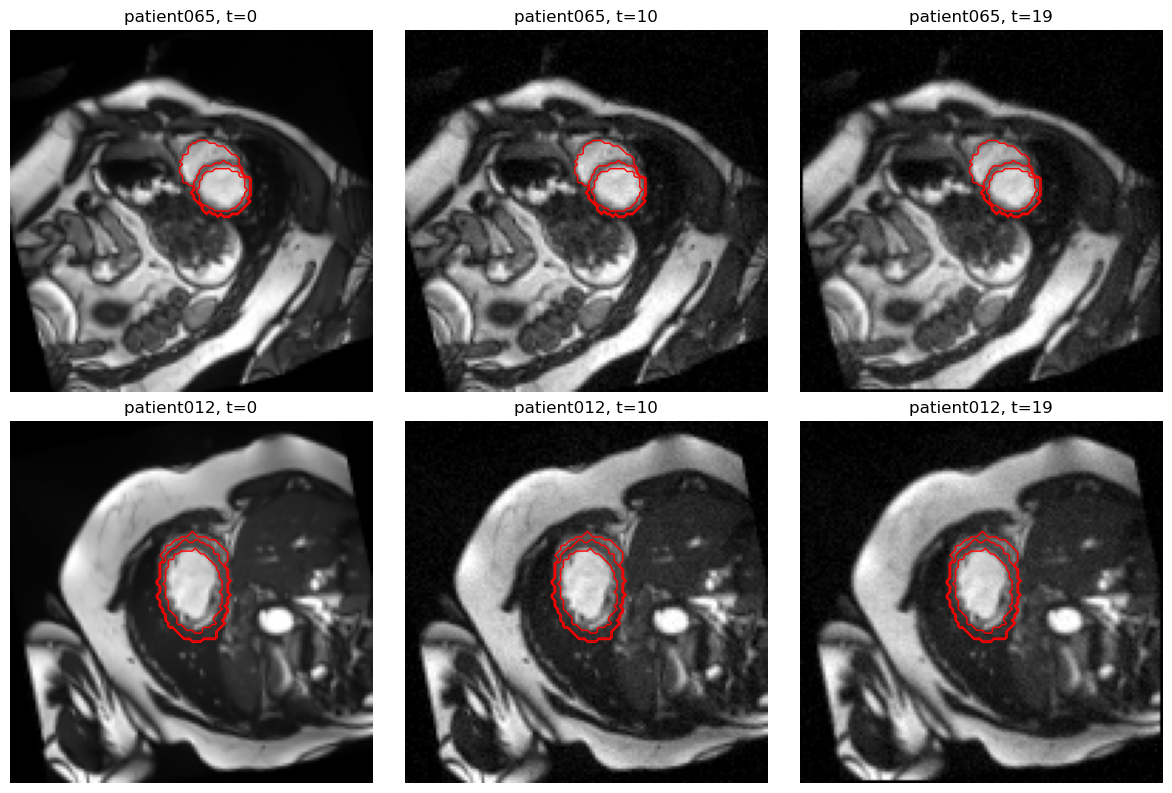

In [43]:
"""
Test ACDC data loading
"""

import matplotlib.pyplot as plt
import torch

# Load data
Config.ACDC_DATA_ROOT = "."
train_loader, val_loader, test_loader = get_acdc_dataloaders(
    data_root=Config.ACDC_DATA_ROOT,
    batch_size=2,
    num_workers=0,
    temporal_frames=20,
    image_size=(128, 128)
)

# Get a sample batch
batch = next(iter(train_loader))
images = batch['image']
labels = batch['label']

print(f"✓ Data loaded: Train={len(train_loader.dataset)}, Val={len(val_loader.dataset)}, Test={len(test_loader.dataset)}")
print(f"✓ Batch shape: Images={images.shape}, Labels={labels.shape}")

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(2):
    for j, t in enumerate([0, 10, 19]):
        img = images[i, t].cpu().numpy()
        lbl = labels[i, t].cpu().numpy()
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].contour(lbl, colors='red', linewidths=1.0, levels=[0.5, 1.5, 2.5, 3.5])
        axes[i, j].set_title(f"{batch['patient_id'][i]}, t={t}")
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()
